## A/B Testing 1: Manual CV vs AI CV Generator

### Hipotesis

In [15]:
# ============================================================
# HYPOTHESIS A/B TESTING 1
# MANUAL CV VS AI CV GENERATOR
# ============================================================

"""
H0:
Tidak terdapat perbedaan completion rate
antara Manual CV dan AI CV Generator.

H1:
AI CV Generator memiliki completion rate
yang lebih tinggi dibanding Manual CV.
"""

'\nH0:\nTidak terdapat perbedaan completion rate\nantara Manual CV dan AI CV Generator.\n\nH1:\nAI CV Generator memiliki completion rate\nyang lebih tinggi dibanding Manual CV.\n'

In [4]:
# Data Preparation
group_A = df[df['group'] == 'A']
group_B = df[df['group'] == 'B']

## Z-Test

In [5]:
z_stat, p_value = proportions_ztest(
    [complete_A, complete_B],
    [n_A, n_B]
)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: -31.045131995617947
P Value: 1.327206102747909e-211


## Interpretasi


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Tolak H0")
    print("AI CV Generator meningkatkan completion rate")
else:
    print("Gagal menolak H0")

### Visualisasi

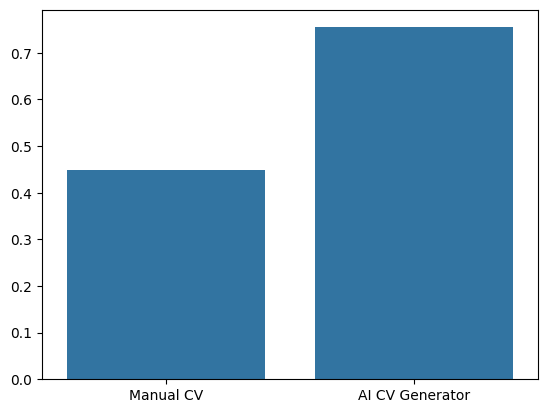

In [6]:
sns.barplot(
    x=['Manual CV', 'AI CV Generator'],
    y=[completion_rate_A, completion_rate_B]
)
plt.show()

## A/B Testing 2: Normal Recommendation vs Explainable AI

### Hipotesis

In [7]:
# ============================================================
# HYPOTHESIS A/B TESTING 2
# EXPLAINABLE AI
# ============================================================

"""
H0:
Tidak terdapat perbedaan trust score
antara Normal Recommendation dan Explainable AI.

H1:
Explainable AI menghasilkan trust score
yang lebih tinggi dibanding Normal Recommendation.
"""

'\nH0:\nTidak terdapat perbedaan trust score\nantara Normal Recommendation dan Explainable AI.\n\nH1:\nExplainable AI menghasilkan trust score\nyang lebih tinggi dibanding Normal Recommendation.\n'

### Mann-Whitney U Test

In [8]:
u_stat, p_value = mannwhitneyu(
    trust_A,
    trust_B,
    alternative='two-sided'
)

### Interpretasi

In [9]:
if p_value < alpha:
    print("Tolak H0")
    print("Explainable AI meningkatkan trust user")
else:
    print("Gagal menolak H0")

Tolak H0
Explainable AI meningkatkan trust user


### Visualisasi

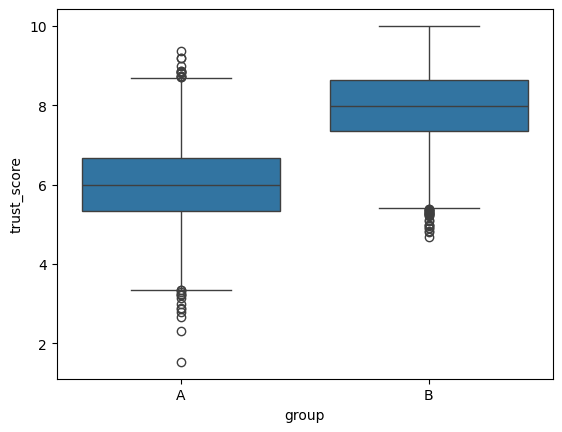

In [10]:
sns.boxplot(
    data=df,
    x='group',
    y='trust_score'
)
plt.show()

## A/B Testing 3: Hard Skill vs Hard + Soft Skill

### Hipotesis

In [11]:
# ============================================================
# HYPOTHESIS A/B TESTING 3
# HARD SKILL VS HARD + SOFT SKILL
# ============================================================

"""
H0:
Tidak terdapat perbedaan relevansi rekomendasi
antara model yang hanya menggunakan Hard Skill
dan model yang menggunakan Hard Skill + Soft Skill.

H1:
Model Hard Skill + Soft Skill menghasilkan
relevansi rekomendasi yang lebih baik.
"""

'\nH0:\nTidak terdapat perbedaan relevansi rekomendasi\nantara model yang hanya menggunakan Hard Skill\ndan model yang menggunakan Hard Skill + Soft Skill.\n\nH1:\nModel Hard Skill + Soft Skill menghasilkan\nrelevansi rekomendasi yang lebih baik.\n'

### T-Test

In [12]:
t_stat, p_value = ttest_ind(
    hard_skill_group,
    combined_group
)

### Interpretasi

In [13]:
if p_value < alpha:
    print("Tolak H0")
    print("Hard + Soft Skill lebih relevan")
else:
    print("Gagal menolak H0")

Gagal menolak H0


### Visualisasi

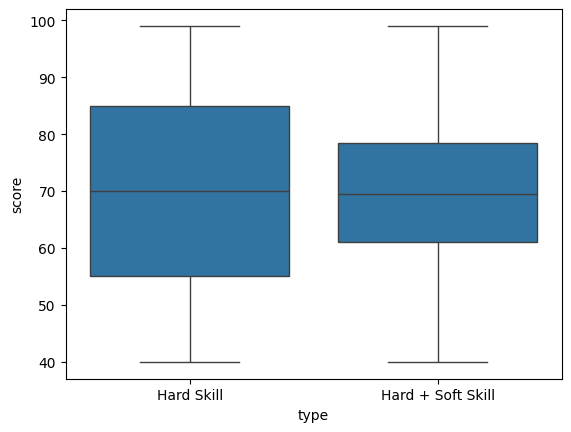

In [14]:
sns.boxplot(
    data=comparison_df,
    x='type',
    y='score'
)
plt.show()


## A/B TESTING 4 Skill Gap Analysis vs Tanpa Skill Gap Analysis

## Hipotesis

In [16]:
# ============================================================
# HYPOTHESIS A/B TESTING 4
# SKILL GAP ANALYSIS
# ============================================================

"""
H0:
Tidak terdapat perbedaan course enrollment
antara pengguna yang melihat Skill Gap Analysis
dan yang tidak melihat Skill Gap Analysis.

H1:
Skill Gap Analysis meningkatkan
course enrollment pengguna.
"""

'\nH0:\nTidak terdapat perbedaan course enrollment\nantara pengguna yang melihat Skill Gap Analysis\ndan yang tidak melihat Skill Gap Analysis.\n\nH1:\nSkill Gap Analysis meningkatkan\ncourse enrollment pengguna.\n'

### Simulasi Data

In [17]:
# ============================================================
# COURSE ENROLLMENT PROBABILITY
# ============================================================

df['course_probability'] = np.where(
    df['group'] == 'A',
    0.30,
    0.55
)

df['course_enrolled'] = np.random.binomial(
    1,
    df['course_probability']
)

### Hitung Conversion

In [18]:
group_A = df[df['group'] == 'A']
group_B = df[df['group'] == 'B']

enroll_A = group_A['course_enrolled'].sum()
enroll_B = group_B['course_enrolled'].sum()

n_A = len(group_A)
n_B = len(group_B)

rate_A = enroll_A / n_A
rate_B = enroll_B / n_B

print("Enrollment Rate A :", rate_A)
print("Enrollment Rate B :", rate_B)

Enrollment Rate A : 0.3189935064935065
Enrollment Rate B : 0.5433467741935484


### Z-Test

In [19]:
z_stat, p_value = proportions_ztest(
    [enroll_A, enroll_B],
    [n_A, n_B]
)

print("Z Statistic :", z_stat)
print("P Value :", p_value)

Z Statistic : -22.521364628823456
P Value : 2.563517540097679e-112


### Interpretasi

In [20]:
alpha = 0.05

if p_value < alpha:
    print("Tolak H0")
    print("Skill Gap Analysis meningkatkan enrollment kursus")
else:
    print("Gagal Menolak H0")
    print("Tidak ada perbedaan signifikan")

Tolak H0
Skill Gap Analysis meningkatkan enrollment kursus


### Visualisasi

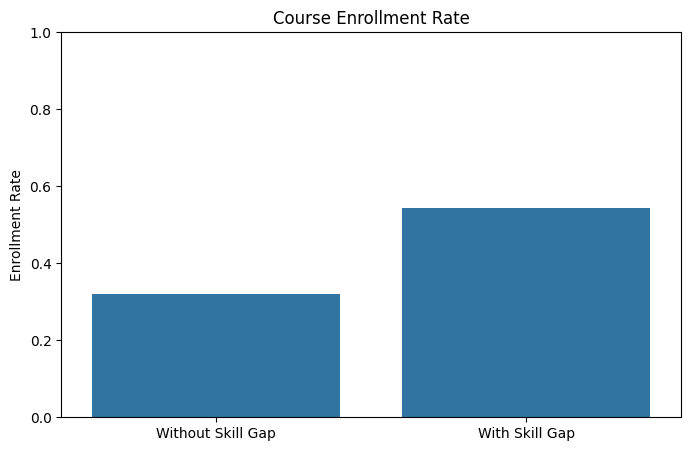

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=[
        'Without Skill Gap',
        'With Skill Gap'
    ],
    y=[
        rate_A,
        rate_B
    ]
)

plt.title('Course Enrollment Rate')
plt.ylabel('Enrollment Rate')
plt.ylim(0,1)

plt.show()